# **Filtro Pasa Todo o Filtro Rotador de Fase**
## Trabajo Semanal 1
### Keila Korj 

## ***Resumen***

En este documento se presenta un analisis numérico, circuital y simbólico de un filtro pasa todo.

Se usarán algunas funciones de PyTC2 para realizar los cálculos y presentar los resultados.

Análisis de la respuesta en frecuencia: analyze_sys

De presentación algebraica: print_latex, a_equal_b_latex_s


## ***Introducción***

A partir del circuito dado:

<center><img src="image.png" width="600"><center>

Se realizó el análisis de la transferencia haciendo uso del método de nodos, quedando 

$$ T(s) = \frac{V_2}{V_1} = \frac{s - \frac{R_2}{R_1} \cdot \frac{1}{R_3 \cdot C_1}}{s + \frac{1}{R_3 \cdot C_1}} $$

Sin embargo al tomar $R1/R2 = 1$, se modifica tal que

$$ T(s) = \frac{s - \frac{1}{R_3 \cdot C_1}}{s + \frac{1}{R_3 \cdot C_1}} $$

tratandose de un filtro pasa todo o también llamado rotador de fase donde dentro de sus aplicaciones se encuentra el prevenir daños en motores, bombas y maquinaria industrial, asegurando que giren en el sentido correcto y evitando fallos en la instalación.

## ***Transferencia Normalizada y Simulación Numérica***

Una vez obtenida la transferencia $T(s)$ fue propuesta la siguiente normalización por impedancia
$$ \Omega_z = R_3 $$
Generando la transferencia normalizada
$$ T(s) = \frac{s - \frac{1}{C_1'}}{s + \frac{1}{C_1'}} $$
Prosiguiendo con la normalización por frecuencia. Como se puede observar, $ \omega_0 = \frac{1}{C_1'} $ por lo tanto la norma de frecuencia será 
$$ \Omega_{\omega 0} = \omega_0 = \frac{1}{C_1'} = \frac{1}{R_3\cdot C_1}  $$

Obteniendo nuevamente la transferencia pero en este caso normalizada también por frecuencia

$$ T(s_n) = \frac{s_n \cdot \Omega_{\omega 0} - \frac{1}{C_1'}}{s_n \cdot \Omega_{\omega 0} + \frac{1}{C_1'}} $$

$$ T(s_n) = \frac{s_n - 1}{s_n + 1} $$


Es a partir de este resultado que se puede realizar el gráfico de módulo, fase y el respetivo diagrama de polos y ceros:

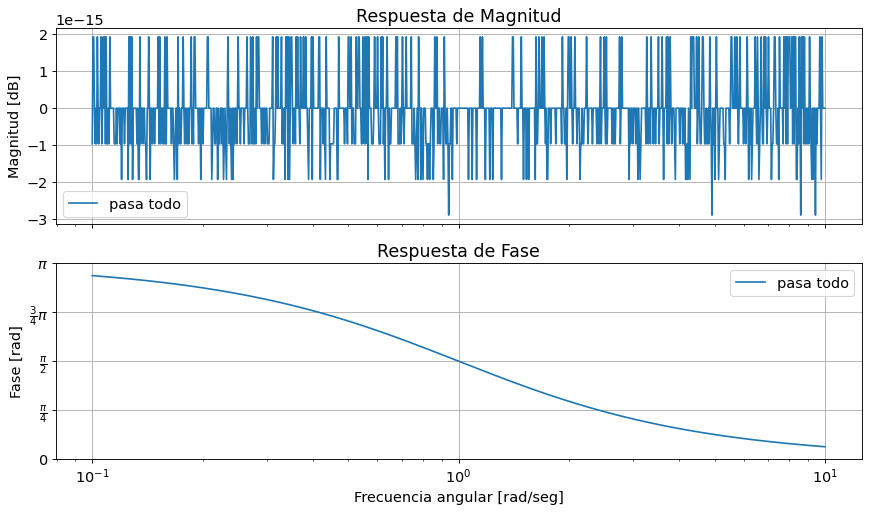

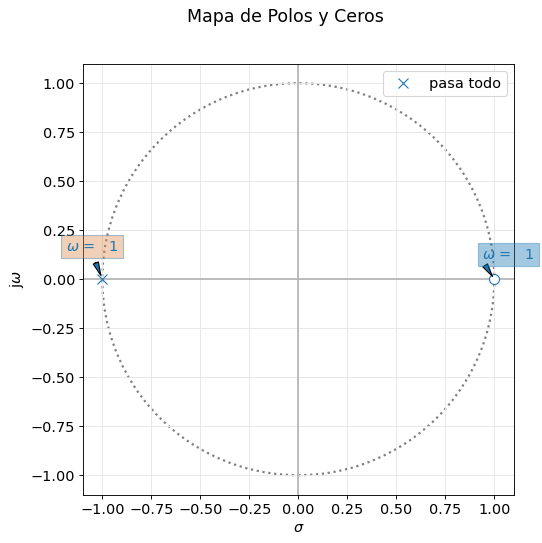

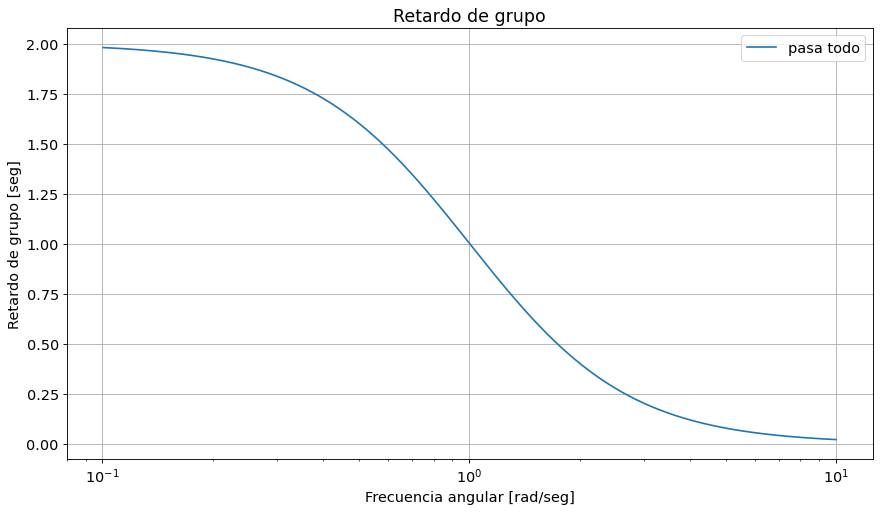

In [9]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

# Cargamos la funcion transferencia como vectores de sus coeficientes.

num = np.array([ 1, -1 ])
den = np.array([ 1., 1 ])

H1 = sig.TransferFunction( num, den )

# Otra forma de analizar el sistema H1, con una función
# de más alto nivel. Podés probarlo si te interesa.

# el caracter "_" descarta la salida de la función
_ = analyze_sys([H1], sys_name='pasa todo')

* Observando el gráfico del módulo se puede apreciar que toma diferentes valores, sin embargo, estos están en el orden de los $10^{-15}dB$, por ende es adecuado decir que el módulo es una línea horizontal en $0dB$ lo cual es correcto si lo que queríamos encontrar era un pasa todo.
  
* A partir de la respuesta de fase y del diagrama de polos y ceros se ve claramente la rotación de fase ya que cuando $\omega_0 \to 0$ el cero y el polo aportan una fase de $\pi$ y $0$ respectivamente, generando una fase total de $\pi$. Pero cuando $\omega_0 \to \infty$ ambos aportan $\frac{\pi}{2}$ y, en consecuancia, el total es $0$.

* Como última observación, en el diagrama de polos y ceros se puede notar la normalización realizada a la transferencia dado que el $\omega_{0_n} = 1$ lo cual corresponde con la distancia existente entre en polo y el origen.

## ***Red Normalizada y Simulación Circuital***

Teniendo en cuenta que ya se habían normalizado dos componentes del circuito, es decir, $R_3$ y $C_1$, y que la tranferencia no dependía de $R_1$ y $R_2$ debido a la igualdad unitaria; se llegó a las siguientes normalizaciones al establecer
$$\Omega_z = R_3 $$
$$\Omega_{w_0} = \frac{1}{C_1'} = \frac{1}{R_3 \cdot C_1}$$

Se obtuvo
$$ R_3' = \frac{R_3}{R_3} = 1$$
$$ C_1'' = C_1\cdot\Omega_z\cdot\Omega_{w_0} = 1$$

* Si tomo $R_1 = R_2 = R_3$
$$R_1' = \frac{R_1}{R_3} = 1$$
$$R_2' = \frac{R_2}{R_3} = 1$$


Quedando la siguiente red

<center><img src="red_normalizada.png" width="600"><center>

modelada en ***LTspice*** y obteniendo el gráfico de la transferencia respectivo


<div align="center">
    <img src="transferencia_spice.png" width="900">
    <br>
    <div style="color: gray; font-size: 0.9em; margin-top: 5px;">
        <b> </b> Respuesta de magnitud (trazo continuo) y fase (trazo punteado) de la transferencia en LTspice
    </div>
</div>

* Observando la curva de módulo es notable que el orden de magnitud de los valores se encuentra en los $10^{-6}dB$ por ende, nuevamente, se llega a la conclusión de que el gráfico representa una horizontal en $0dB$ correspondiendo a lo esperado de un filtro pasa todo.
* La fase (trazo punteado) hace su recorrido desde $\pi rad$ en las frecuencias más bajas hasta $0 rad$ para las frecuencias más altas. Pero lo interesante es que, a partir de la implementación del cursor, cuando la fase está en aproximadamente $\frac{\pi}{2} rad$ la frecuancia se encuentra en aproximadamente $158,31 mHz$ lo cual nos da un indicio de nuestra $\omega_0$ dado que esa fase sería "el camino medio" entre nuestra fase máxima y mínima. Sin embargo, sus unidades son $\frac{rad}{seg}$. Está claro que $\omega_0 = 2\pi.f_0$, por lo tanto se realiza el siguiente cálculo: 

$$\omega_0 = 2\pi f$$
$$f_0 = \frac{\omega_0}{2\pi}$$
<center>Si tomamos $\omega_{0_n} = 1$</center>
$$f_0 = \frac{1}{2\pi} \approx 0,159Hz \approx 159mHz $$



Se evidencia de este modo una gran similitud entre el valor teórico y el obtenido en la simulación.

## ***Verificación y Simulación Simbólica***

A través del próximo código se realizó la simulación simbólica tanto para resolver la transferecia desnormalizada como la normalizada:

In [9]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot

# tensiones y corrientes que usaremos para nuestros análisis
V1, V2, Va = sp.symbols("V1, V2, Va")
Y1, Y2, Y3, Yc = sp.symbols("Y1, Y2, Y3, Yc")
R1, R2, R3, C1 = sp.symbols("R1, R2, R3, C1")



aa = sp.solve([ 
                Va*(Y3 + Yc) - V1*Yc, Va*(Y1 + Y2) - V1*Y1 - V2*Y2
                ], 
                [V1, V2, Va])
T_s = aa[V2]/aa[V1]

T_s1=sp.simplify(sp.expand(T_s.subs({Y1:1/R1, Y2:1/R2, Y3:1/R3, Yc:s*C1})))

print_latex(a_equal_b_latex_s('T(s)= \\frac{V_2}{V_1}', T_s1))


#Chequeo con normalización

O_z, O_w0, s, s_n = sp.symbols("O_z, O_w0, s, s_")

aa = sp.solve([ 
                Va*(Y3 + Yc) - V1*Yc, Va*(Y1 + Y2) - V1*Y1 - V2*Y2
                ], 
                [V1, V2, Va])
T_s = aa[V2]/aa[V1]

T_s1=sp.simplify(sp.expand(T_s.subs({O_z:R3, O_w0: 1/(R3*C1), s: (s_n)*O_w0, Y1:1/(R1/O_z), Y2:1/(R2/O_z), Y3:1/(R3/O_z), Yc:s*(C1*O_z)})))

# En Yc:s*(C1*O_z) solo pongo el O_z porque al ya reemplazar s por s: (s_n)*O_w0 ahí ya incluyo a O_w0

print_latex(a_equal_b_latex_s('T_n(s)= \\frac{V_2}{V_1}', T_s1))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Donde realizando factor común y reemplazando: $$O_{w0} = \Omega_{w_0} = \frac{1}{R_3C_1}$$ 
$$\frac{R_2}{R_1} = 1$$
resultan las tranferencias previamente calculadas en la ***Introducción*** y en ***Transferencia Normalizada y Simulación Numérica***, donde:
$$ T(s) = \frac{s - \frac{1}{R_3 \cdot C_1}}{s + \frac{1}{R_3 \cdot C_1}} $$
$$ T_n(s) = \frac{s - 1}{s + 1} $$

## ***Conclusión***

Los resultados obtenidos matemáticamente concordaron con los adquiridos en las distintas instancias de simulación (numérica, circuital y simbólica) denotando el funcionamiento y forma del filtro pasa todo.